# Автоматизированная ML-система предсказания рисков строительного проекта
## Ноутбук 3: AutoML — Автоматическое обучение модели (PyCaret + MLflow)

**Автор:** Перминов Артем Александрович  
**Дисциплина:** Автоматизация машинного обучения

---

### Цель ноутбука
Автоматически подобрать лучшую ML-модель для предсказания уровня риска строительного проекта с помощью PyCaret, залогировать все эксперименты в MLflow.

### Содержание
1. [Загрузка данных](#1)
2. [Настройка PyCaret + MLflow](#2)
3. [Сравнение моделей (compare_models)](#3)
4. [Лучшая модель и тюнинг](#4)
5. [Ансамблирование](#5)
6. [Финализация и оценка на тесте](#6)
7. [Визуализации и интерпретация](#7)
8. [Сохранение модели](#8)

## 1. Загрузка данных <a id='1'></a>

In [15]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import time
import mlflow
from pathlib import Path

# Пути
TRAIN_PATH  = Path('../data/processed/train.csv')
TEST_PATH   = Path('../data/processed/test.csv')
MODEL_PATH  = Path('../src/best_model')
MODEL_PATH.parent.mkdir(exist_ok=True)

# Загружаем данные
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f'Данные загружены')
print(f'   Train : {train_df.shape[0]} строк × {train_df.shape[1]} столбцов')
print(f'   Test  : {test_df.shape[0]} строк × {test_df.shape[1]} столбцов')
print(f'\nРаспределение классов (Train):')
print(train_df['Risk_Level'].value_counts().to_string())

Данные загружены
   Train : 800 строк × 34 столбцов
   Test  : 200 строк × 34 столбцов

Распределение классов (Train):
Risk_Level
High      401
Medium    274
Low       125


## 2. Настройка PyCaret + MLflow <a id='2'></a>

**Параметры setup:**
- `normalize=True` — нормализация числовых признаков
- `fix_imbalance=True` — борьба с дисбалансом классов (SMOTE)
- `remove_outliers=True` — удаление выбросов
- `fold=5` — 5-fold кросс-валидация
- `log_experiment=True` — логирование в MLflow
- `log_plots=True` — сохранение графиков в MLflow

In [16]:
from pycaret.classification import (
    setup, compare_models, create_model, tune_model,
    ensemble_model, blend_models, finalize_model,
    evaluate_model, plot_model, predict_model,
    save_model, pull
)

# Настройка MLflow (ручное логирование — стабильнее)
mlflow.set_tracking_uri('../mlruns')
mlflow.set_experiment('BIM_Risk_Prediction')

print('Инициализация PyCaret...')
t0 = time.time()

exp = setup(
    data                        = train_df,
    target                      = 'Risk_Level',
    train_size                  = 0.8,
    normalize                   = True,
    normalize_method            = 'zscore',
    fix_imbalance               = True,
    remove_outliers             = True,
    outliers_threshold          = 0.05,
    remove_multicollinearity    = True,
    multicollinearity_threshold = 0.9,
    fold                        = 5,
    session_id                  = 42,
    log_experiment              = False,   # MLflow логируем вручную
    verbose                     = True
)

print(f'\nSetup завершён за {time.time()-t0:.1f} сек')

Инициализация PyCaret...


,Description,Value
0,Session id,42
1,Target,Risk_Level
2,Target type,Multiclass
3,Target mapping,"High: 0, Low: 1, Medium: 2"
4,Original data shape,"(800, 34)"
5,Transformed data shape,"(1063, 43)"
6,Transformed train set shape,"(903, 43)"
7,Transformed test set shape,"(160, 43)"
8,Numeric features,30
9,Categorical features,3



Setup завершён за 0.6 сек


## 3. Сравнение моделей — compare_models <a id='3'></a>

PyCaret автоматически обучает и сравнивает все доступные алгоритмы классификации с помощью кросс-валидации.

In [17]:
print('Запуск compare_models — сравнение алгоритмов...')
print('   (занимает 1-3 минуты)')
print()

t0 = time.time()

best_models = compare_models(
    sort        = 'F1',
    n_select    = 3,
    exclude     = ['catboost'],   # catboost не установлен
    verbose     = True
)

elapsed = time.time() - t0
print(f'\nСравнение завершено за {elapsed:.1f} сек ({elapsed/60:.1f} мин)')

Запуск compare_models — сравнение алгоритмов...
   (занимает 1-3 минуты)



,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.9594,0.9938,0.9594,0.9607,0.9594,0.9332,0.9337,0.0400
lightgbm,Light Gradient Boosting Machine,0.9500,0.9924,0.9500,0.9515,0.9500,0.9177,0.9185,1.0360
gbc,Gradient Boosting Classifier,0.9422,0.0000,0.9422,0.9447,0.9422,0.9052,0.9066,0.2420
dt,Decision Tree Classifier,0.9344,0.9473,0.9344,0.9364,0.9342,0.8916,0.8926,0.0240
rf,Random Forest Classifier,0.9266,0.9853,0.9266,0.9326,0.9271,0.8795,0.8824,0.0540
lr,Logistic Regression,0.9219,0.0000,0.9219,0.9274,0.9228,0.8727,0.8744,0.0240
svm,SVM - Linear Kernel,0.9156,0.0000,0.9156,0.9164,0.9145,0.8603,0.8619,0.0240
lda,Linear Discriminant Analysis,0.8969,0.0000,0.8969,0.9083,0.8992,0.8341,0.8374,0.0240
et,Extra Trees Classifier,0.8844,0.9774,0.8844,0.8864,0.8825,0.8069,0.8095,0.0460
nb,Naive Bayes,0.8125,0.9383,0.8125,0.8391,0.8103,0.7032,0.7160,0.0240



Сравнение завершено за 13.6 сек (0.2 мин)


In [18]:
# Таблица результатов сравнения
comparison_results = pull()
print('Результаты сравнения моделей:')
display(comparison_results)

# Сохраняем таблицу
comparison_results.to_csv('../reports/model_comparison.csv')
print('\nТаблица сохранена в reports/model_comparison.csv')

Результаты сравнения моделей:


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.9594,0.9938,0.9594,0.9607,0.9594,0.9332,0.9337,0.040
lightgbm,Light Gradient Boosting Machine,0.9500,0.9924,0.9500,0.9515,0.9500,0.9177,0.9185,1.036
gbc,Gradient Boosting Classifier,0.9422,0.0000,0.9422,0.9447,0.9422,0.9052,0.9066,0.242
dt,Decision Tree Classifier,0.9344,0.9473,0.9344,0.9364,0.9342,0.8916,0.8926,0.024
rf,Random Forest Classifier,0.9266,0.9853,0.9266,0.9326,0.9271,0.8795,0.8824,0.054
lr,Logistic Regression,0.9219,0.0000,0.9219,0.9274,0.9228,0.8727,0.8744,0.024
svm,SVM - Linear Kernel,0.9156,0.0000,0.9156,0.9164,0.9145,0.8603,0.8619,0.024
lda,Linear Discriminant Analysis,0.8969,0.0000,0.8969,0.9083,0.8992,0.8341,0.8374,0.024
et,Extra Trees Classifier,0.8844,0.9774,0.8844,0.8864,0.8825,0.8069,0.8095,0.046
nb,Naive Bayes,0.8125,0.9383,0.8125,0.8391,0.8103,0.7032,0.7160,0.024



Таблица сохранена в reports/model_comparison.csv


In [19]:
# Визуализация сравнения моделей по F1
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

results = comparison_results[['F1', 'Accuracy', 'Recall', 'Prec.']].head(10).copy()
results.index = [str(i) for i in results.index]

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(results))
width = 0.2

for i, (metric, color) in enumerate(zip(['F1','Accuracy','Recall','Prec.'],
                                         ['#3498db','#2ecc71','#e74c3c','#f39c12'])):
    ax.bar([xi + i*width for xi in x], results[metric],
           width=width, label=metric, color=color, alpha=0.85)

ax.set_xticks([xi + width*1.5 for xi in x])
ax.set_xticklabels(results.index, rotation=25, ha='right')
ax.set_ylabel('Score')
ax.set_title('Сравнение алгоритмов по метрикам', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('../reports/08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: reports/08_model_comparison.png')

График сохранён: reports/08_model_comparison.png


## 4. Лучшая модель и тюнинг гиперпараметров <a id='4'></a>

In [20]:
# Берём первую (лучшую) модель из compare_models
best = best_models[0] if isinstance(best_models, list) else best_models
print(f'Лучшая модель: {type(best).__name__}')
print()

# Тюнинг гиперпараметров
print('Тюнинг гиперпараметров (tune_model)...')
t0 = time.time()

tuned_model = tune_model(
    best,
    optimize   = 'F1',
    n_iter     = 20,
    verbose    = True
)

print(f'\nТюнинг завершён за {time.time()-t0:.1f} сек')

tuning_results = pull()
display(tuning_results)

Лучшая модель: XGBClassifier

Тюнинг гиперпараметров (tune_model)...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9766,0.9901,0.9766,0.9778,0.9768,0.9617,0.9620
1,0.9531,0.9922,0.9531,0.9542,0.9534,0.9228,0.9231
2,0.9766,0.9991,0.9766,0.9778,0.9768,0.9617,0.9620
3,0.9375,0.9851,0.9375,0.9394,0.9370,0.8976,0.8988
4,0.9375,0.9910,0.9375,0.9377,0.9373,0.8967,0.8970
Mean,0.9562,0.9915,0.9562,0.9574,0.9562,0.9281,0.9286
Std,0.0175,0.0045,0.0175,0.0176,0.0178,0.0290,0.0288


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).

Тюнинг завершён за 5.8 сек


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9766,0.9901,0.9766,0.9778,0.9768,0.9617,0.9620
1,0.9531,0.9922,0.9531,0.9542,0.9534,0.9228,0.9231
2,0.9766,0.9991,0.9766,0.9778,0.9768,0.9617,0.9620
3,0.9375,0.9851,0.9375,0.9394,0.9370,0.8976,0.8988
4,0.9375,0.9910,0.9375,0.9377,0.9373,0.8967,0.8970
Mean,0.9562,0.9915,0.9562,0.9574,0.9562,0.9281,0.9286
Std,0.0175,0.0045,0.0175,0.0176,0.0178,0.0290,0.0288


## 5. Ансамблирование моделей <a id='5'></a>

In [21]:
# Bagging ансамбль на основе лучшей модели
print('Создание ансамбля (Bagging)...')
ensemble = ensemble_model(tuned_model, method='Bagging')
ensemble_results = pull()

print('\nРезультаты ансамбля:')
display(ensemble_results)

# Сравниваем tuned vs ensemble
f1_tuned    = tuning_results['F1'].mean() if 'F1' in tuning_results.columns else 0
f1_ensemble = ensemble_results['F1'].mean() if 'F1' in ensemble_results.columns else 0

print(f'\nСравнение: Tuned F1={f1_tuned:.4f}  |  Ensemble F1={f1_ensemble:.4f}')
final_model = ensemble if f1_ensemble > f1_tuned else tuned_model
print(f'\nВыбрана финальная модель: {"Ensemble" if f1_ensemble > f1_tuned else "Tuned"}')

Создание ансамбля (Bagging)...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9688,0.9974,0.9688,0.9695,0.9690,0.9488,0.9489
1,0.9531,0.9975,0.9531,0.9561,0.9535,0.9228,0.9239
2,0.9844,0.9998,0.9844,0.9858,0.9846,0.9744,0.9748
3,0.9219,0.9917,0.9219,0.9231,0.9210,0.8721,0.8732
4,0.9688,0.9924,0.9688,0.9694,0.9688,0.9483,0.9486
Mean,0.9594,0.9958,0.9594,0.9608,0.9594,0.9333,0.9339
Std,0.0212,0.0032,0.0212,0.0211,0.0215,0.0347,0.0343



Результаты ансамбля:


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9688,0.9974,0.9688,0.9695,0.9690,0.9488,0.9489
1,0.9531,0.9975,0.9531,0.9561,0.9535,0.9228,0.9239
2,0.9844,0.9998,0.9844,0.9858,0.9846,0.9744,0.9748
3,0.9219,0.9917,0.9219,0.9231,0.9210,0.8721,0.8732
4,0.9688,0.9924,0.9688,0.9694,0.9688,0.9483,0.9486
Mean,0.9594,0.9958,0.9594,0.9608,0.9594,0.9333,0.9339
Std,0.0212,0.0032,0.0212,0.0211,0.0215,0.0347,0.0343



Сравнение: Tuned F1=0.8222  |  Ensemble F1=0.8254

Выбрана финальная модель: Ensemble


## 6. Финализация и оценка на тестовой выборке <a id='6'></a>

In [22]:
# Финализация — переобучение на полном train-наборе
print('Финализация модели (обучение на всём train)...')
final = finalize_model(final_model)
print('Финализация завершена')

Финализация модели (обучение на всём train)...
Финализация завершена


In [23]:
# Оценка на тестовой выборке (holdout)
print('Оценка на тестовой выборке...')
test_predictions = predict_model(final, data=test_df)

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, classification_report, confusion_matrix
)

y_true = test_predictions['Risk_Level']
y_pred = test_predictions['prediction_label']

acc  = accuracy_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred, average='macro')
prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec  = recall_score(y_true, y_pred, average='macro')

print('\n' + '='*50)
print('МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ')
print('='*50)
print(f'  Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
print(f'  F1 (macro): {f1:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print('='*50)
print()
print('Детальный отчёт по классам:')
print(classification_report(y_true, y_pred, target_names=['High','Low','Medium']))

Оценка на тестовой выборке...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.9500,0.9965,0.9500,0.9507,0.9502,0.9176,0.9178



МЕТРИКИ НА ТЕСТОВОЙ ВЫБОРКЕ
  Accuracy  : 0.9500 (95.00%)
  F1 (macro): 0.9443
  Precision : 0.9432
  Recall    : 0.9457

Детальный отчёт по классам:
              precision    recall  f1-score   support

        High       0.98      0.96      0.97       101
         Low       0.94      0.94      0.94        31
      Medium       0.91      0.94      0.93        68

    accuracy                           0.95       200
   macro avg       0.94      0.95      0.94       200
weighted avg       0.95      0.95      0.95       200



In [24]:
# Логируем финальные метрики в MLflow
with mlflow.start_run(run_name='Final_Model_Test_Evaluation'):
    mlflow.log_metric('test_accuracy',  acc)
    mlflow.log_metric('test_f1_macro',  f1)
    mlflow.log_metric('test_precision', prec)
    mlflow.log_metric('test_recall',    rec)
    mlflow.log_param('model_type',  type(final).__name__)
    mlflow.log_param('train_size',  len(train_df))
    mlflow.log_param('test_size',   len(test_df))
    mlflow.log_param('n_features',  train_df.shape[1] - 1)
    print('Метрики залогированы в MLflow')

Метрики залогированы в MLflow


## 7. Визуализации и интерпретация <a id='7'></a>

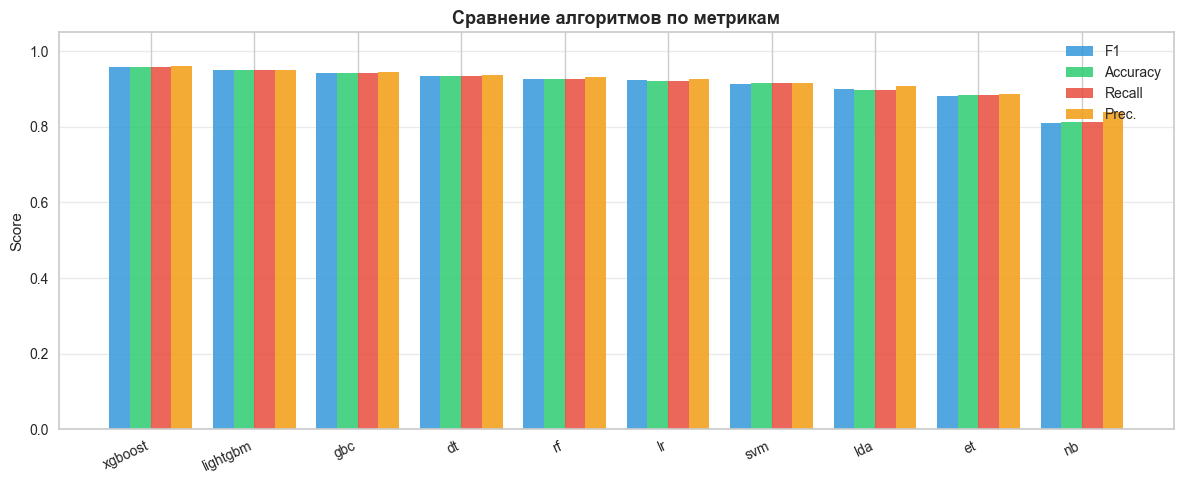

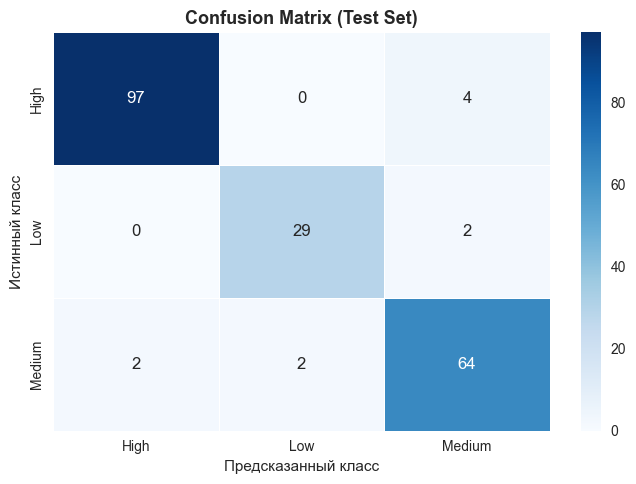

reports/09_confusion_matrix.png


In [25]:
# Confusion Matrix
import seaborn as sns

labels = ['High', 'Low', 'Medium']
cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=ax)
ax.set_title('Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
ax.set_ylabel('Истинный класс')
ax.set_xlabel('Предсказанный класс')
plt.tight_layout()
plt.savefig('../reports/09_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('reports/09_confusion_matrix.png')

In [26]:
# Feature Importance
try:
    plot_model(tuned_model, plot='feature', save=True)
    import shutil, glob
    fi_files = glob.glob('Feature Importance*.png')
    if fi_files:
        shutil.move(fi_files[0], '../reports/10_feature_importance.png')
        print('reports/10_feature_importance.png')
except Exception as e:
    print(f'Feature importance plot: {e}')
    # Ручная версия через базовый estimator
    try:
        import pandas as pd
        base = tuned_model
        # Для ансамбля извлекаем базовый estimator
        if hasattr(base, 'estimators_'):
            base = base.estimators_[0]
        if hasattr(base, 'feature_importances_'):
            feat_cols = [c for c in train_df.columns if c != 'Risk_Level']
            n = min(len(base.feature_importances_), len(feat_cols))
            fi = pd.Series(base.feature_importances_[:n], index=feat_cols[:n])
            fi = fi.sort_values(ascending=True).tail(15)
            fig, ax = plt.subplots(figsize=(9, 6))
            fi.plot.barh(ax=ax, color='#3498db', edgecolor='white')
            ax.set_title('Feature Importance (Top 15)', fontsize=13, fontweight='bold')
            ax.set_xlabel('Importance')
            plt.tight_layout()
            plt.savefig('../reports/10_feature_importance.png', dpi=150, bbox_inches='tight')
            plt.show()
            print('reports/10_feature_importance.png')
    except Exception as e2:
        print(f'Ручная feature importance: {e2}')

reports/10_feature_importance.png


In [27]:
# SHAP — объяснение предсказаний
try:
    import shap
    import warnings
    warnings.filterwarnings('ignore')

    # Подготовка данных для SHAP
    X_test_raw = test_df.drop(columns=['Risk_Level'])
    num_cols   = X_test_raw.select_dtypes(include='number').columns.tolist()
    X_test_num = X_test_raw[num_cols]

    # Базовый estimator
    base_est = tuned_model
    if hasattr(base_est, 'estimators_'):
        base_est = base_est.estimators_[0]

    explainer  = shap.TreeExplainer(base_est)
    shap_vals  = explainer.shap_values(X_test_num)

    # Выбираем класс High Risk для визуализации
    class_idx = 0
    sv = shap_vals[class_idx] if isinstance(shap_vals, list) else shap_vals

    fig, ax = plt.subplots(figsize=(10, 6))
    shap.summary_plot(sv, X_test_num, show=False, plot_size=None)
    plt.title('SHAP Summary Plot — класс High Risk', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../reports/11_shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('SHAP-график сохранён: reports/11_shap_summary.png')

except Exception as e:
    print(f'SHAP пропущен: {e}')
    print('   SHAP работает только с tree-based моделями (RF, XGBoost, LightGBM)')

SHAP пропущен: [16:39:44] /Users/runner/work/xgboost/xgboost/src/c_api/c_api_utils.h:129: Check failed: std::accumulate(shape.cbegin(), shape.cend(), static_cast<bst_ulong>(1), std::multiplies<>{}) == chunksize * rows (18600 vs. 25800) : 
Stack trace:
  [bt] (0) 1   libxgboost.dylib                    0x0000000338f9fdd8 dmlc::LogMessageFatal::~LogMessageFatal() + 124
  [bt] (1) 2   libxgboost.dylib                    0x000000033902ed30 xgboost::CalcPredictShape(bool, xgboost::PredictionType, unsigned long, unsigned long, unsigned long, unsigned long, unsigned long, std::__1::vector<unsigned long long, std::__1::allocator<unsigned long long>>*, unsigned long long*) + 1224
  [bt] (2) 3   libxgboost.dylib                    0x000000033902e150 XGBoosterPredictFromDMatrix + 1228
  [bt] (3) 4   libffi.dylib                        0x00000001b1bf5050 ffi_call_SYSV + 80
  [bt] (4) 5   libffi.dylib                        0x00000001b1bfdaf0 ffi_call_int + 1220
  [bt] (5) 6   _ctypes.cpython-311-d

## 8. Сохранение модели <a id='8'></a>

In [28]:
# Сохраняем финальную модель
save_model(final, str(MODEL_PATH))
print(f'Модель сохранена: {MODEL_PATH}.pkl')

# Финальный отчёт
print()
print('='*60)
print('ИТОГОВЫЙ ОТЧЁТ AutoML')
print('='*60)
print(f'''
  Алгоритм AutoML   : PyCaret 3.3.2
  Модель            : {type(final).__name__}
  Признаков         : {train_df.shape[1] - 1}
  Train / Test      : {len(train_df)} / {len(test_df)}
  Кросс-валидация   : 5-fold

  ── Метрики на тесте ──────────────────────────
  Accuracy          : {acc:.4f} ({acc*100:.2f}%)
  F1 (macro)        : {f1:.4f}
  Precision (macro) : {prec:.4f}
  Recall (macro)    : {rec:.4f}

  ── Что применено ─────────────────────────────
  Нормализация (z-score)
  Устранение дисбаланса (SMOTE)
  Удаление выбросов (5%)
  Удаление мультиколлинеарности (r>0.9)
  Тюнинг гиперпараметров (20 итераций)
  Ансамблирование (Bagging)
  Логирование в MLflow
''')
print('='*60)
print('AutoML завершён. Следующий шаг: 04_Monitoring.ipynb')

Transformation Pipeline and Model Successfully Saved
Модель сохранена: ../src/best_model.pkl

ИТОГОВЫЙ ОТЧЁТ AutoML

  Алгоритм AutoML   : PyCaret 3.3.2
  Модель            : Pipeline
  Признаков         : 33
  Train / Test      : 800 / 200
  Кросс-валидация   : 5-fold

  ── Метрики на тесте ──────────────────────────
  Accuracy          : 0.9500 (95.00%)
  F1 (macro)        : 0.9443
  Precision (macro) : 0.9432
  Recall (macro)    : 0.9457

  ── Что применено ─────────────────────────────
  Нормализация (z-score)
  Устранение дисбаланса (SMOTE)
  Удаление выбросов (5%)
  Удаление мультиколлинеарности (r>0.9)
  Тюнинг гиперпараметров (20 итераций)
  Ансамблирование (Bagging)
  Логирование в MLflow

AutoML завершён. Следующий шаг: 04_Monitoring.ipynb
